**Aktivitas Hands-on pertemuan 11**

Nama: Bagas Aditiya

NIM: 240401010141

Kelas: IF - 403

In [14]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

Melakukan Eksplorasi dataset dan generate

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


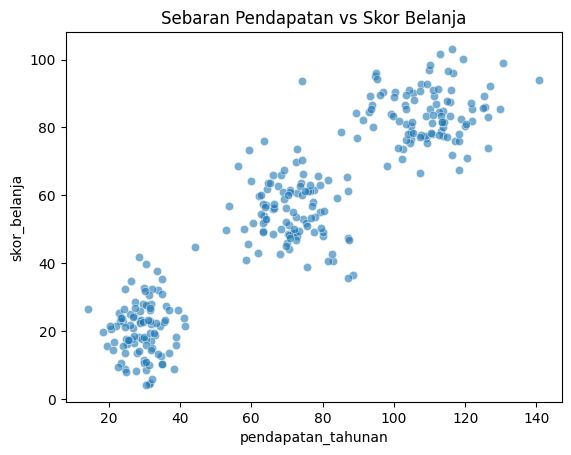

In [2]:
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))
print('Shape:', df.shape)
print(df.describe().round(2))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

Preprocessing Data

In [3]:
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


Menggunakan metode Elbow untuk menentukan K

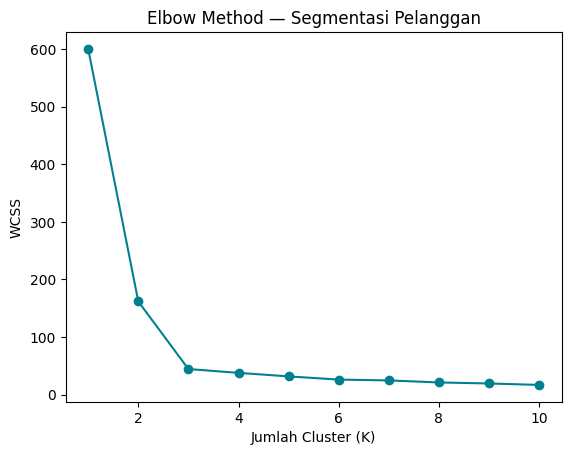

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

Melatih Model K-Means

In [10]:
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


Melakukan Visualisasi hasil Clustering

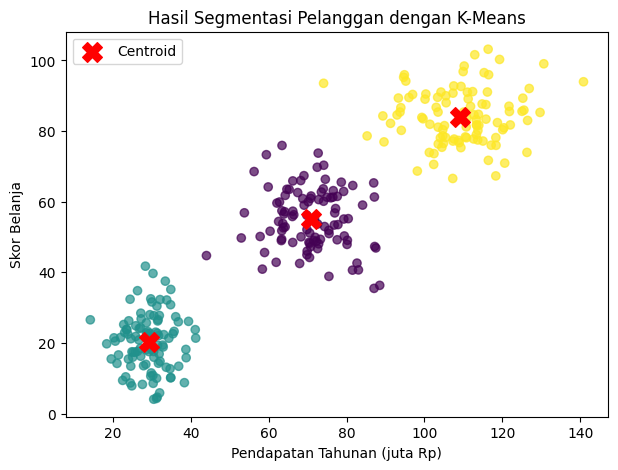

In [13]:
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1],
c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Hasil Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()

Hierarchical Clustering

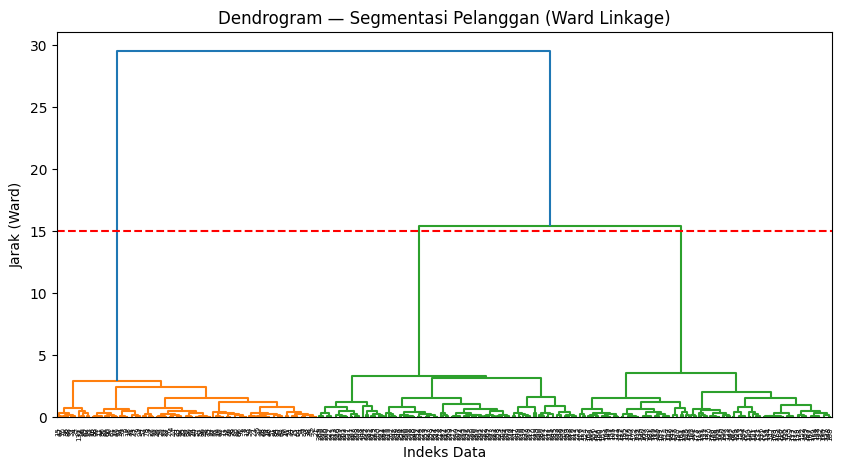

In [15]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()

Pada pertemuan ke-11 kali ini, saya mempelajari algoritma K-Means Clustering sebagai salah satu metode Unsupervised Learning untuk melakukan segmentasi pelanggan. Proses yang dilakukan meliputi pembuatan dataset sintetis, preprocessing menggunakan StandardScaler, penentuan jumlah cluster optimal dengan Metode Elbow, pelatihan model K-Means, visualisasi hasil clustering, serta perbandingan menggunakan Hierarchical Clustering. Hasil yang diperoleh menunjukkan bahwa jumlah cluster optimal adalah tiga, sesuai dengan karakteristik data yang dibentuk, sehingga pelanggan dapat dikelompokkan menjadi segmen Hemat, Menengah, dan Premium/Boros. Dari praktikum ini, saya memahami bahwa clustering dapat membantu perusahaan mengenali karakteristik pelanggan tanpa memerlukan label data, sehingga dapat dimanfaatkan sebagai dasar penyusunan strategi pemasaran dan pelayanan yang lebih tepat sasaran.